# Performance Analytics of Mutual Funds

This notebook analyzes the historical performance of 40 mutual fund schemes using various financial performance metrics. The analysis includes return calculation, CAGR, risk-adjusted metrics, Alpha & Beta estimation, Maximum Drawdown, Fund Scorecard generation, and Benchmark comparison.

In [191]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

## Task 1: Daily Returns & Annualised Returns

Compute daily returns for each mutual fund using percentage change in NAV. Calculate annualised returns from the daily returns and validate the return distribution using histograms.

In [192]:
nav_df=pd.read_csv(r"D:\Bluestock\Project\Data\Processed\clean_nav_history.csv")
nav_df.head()

,date,amfi_code,nav
0,2022-01-03,100016,520.4608
1,2022-01-04,100016,515.0971
2,2022-01-05,100016,521.7239
3,2022-01-06,100016,515.7880
4,2022-01-07,100016,515.1639


In [193]:
nav_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64320 entries, 0 to 64319
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       64320 non-null  str    
 1   amfi_code  64320 non-null  int64  
 2   nav        64320 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.5 MB


In [194]:
nav_df["date"]=pd.to_datetime(nav_df["date"])

In [195]:
nav_df=nav_df.sort_values(["amfi_code","date"])

In [196]:
nav_df["daily_return"]=nav_df.groupby("amfi_code").nav.pct_change()

In [197]:
nav_df["daily_return"].describe()

count    64280.000000
mean         0.000451
std          0.008706
min         -0.058102
25%         -0.002092
50%          0.000000
75%          0.003233
max          0.064713
Name: daily_return, dtype: float64

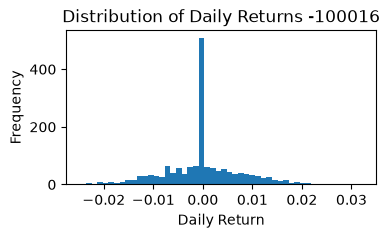

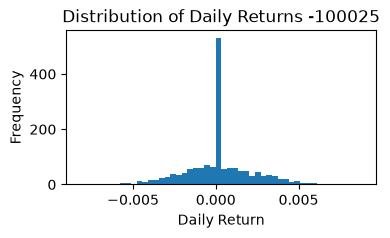

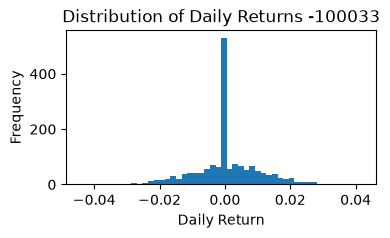

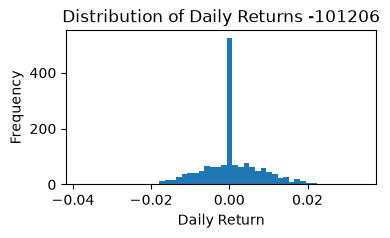

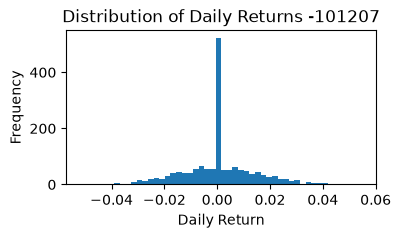

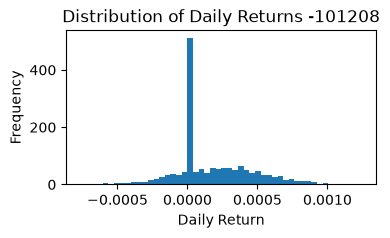

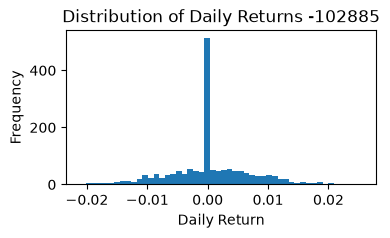

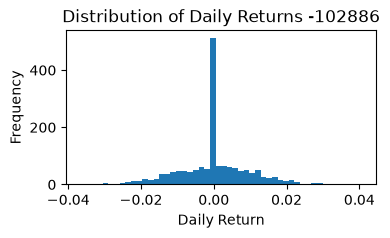

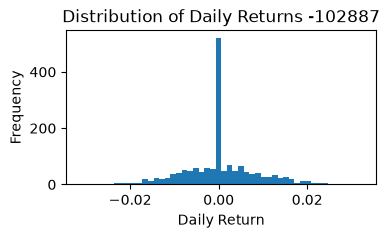

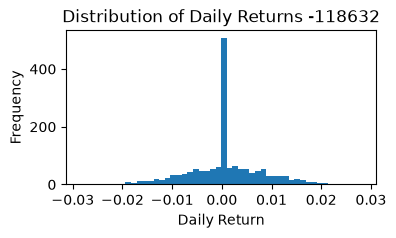

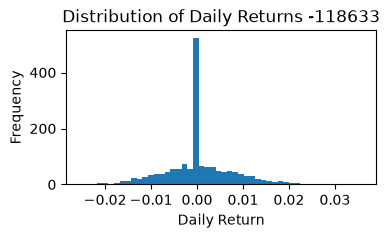

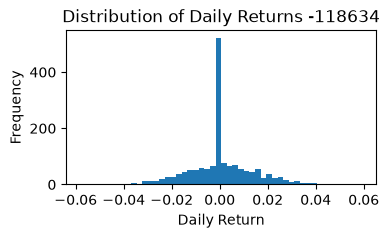

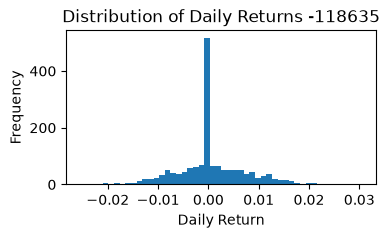

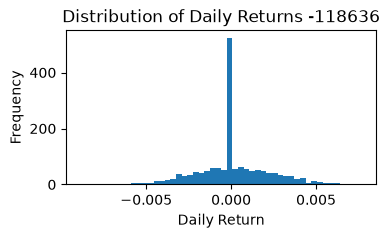

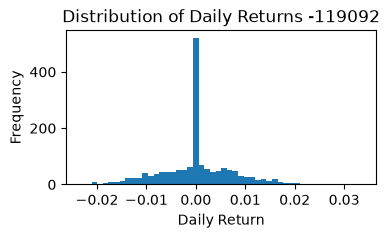

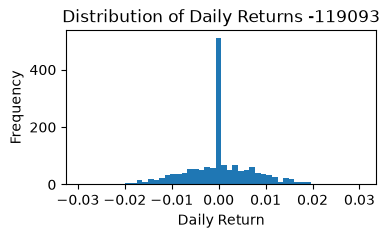

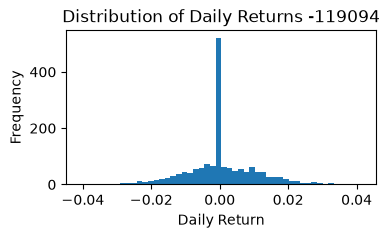

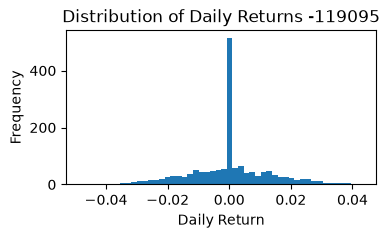

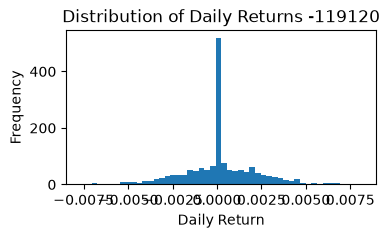

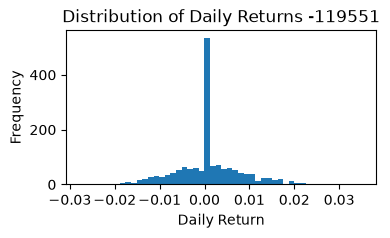

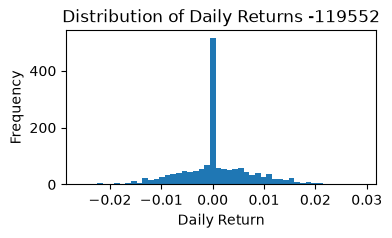

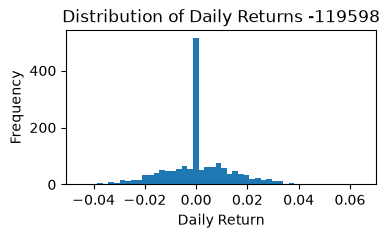

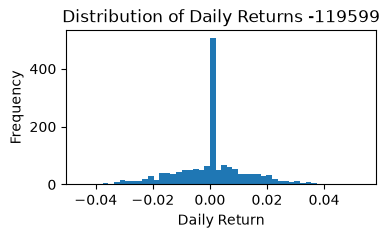

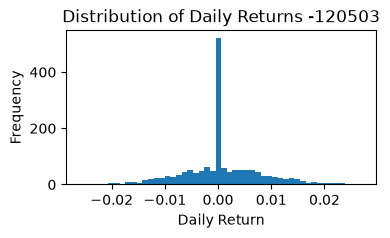

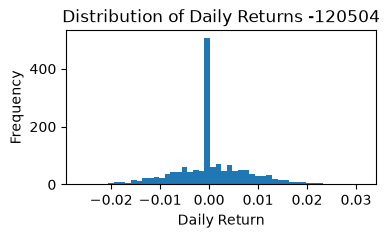

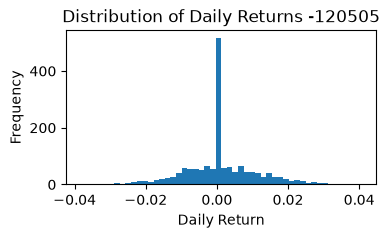

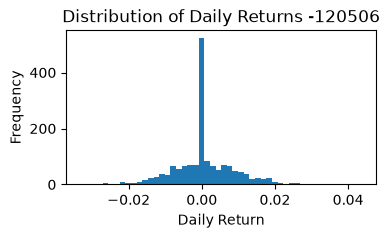

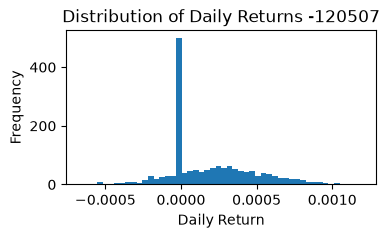

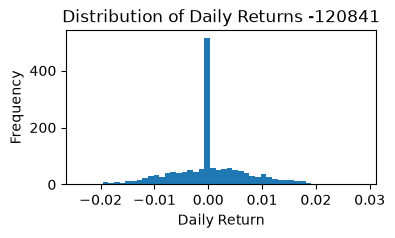

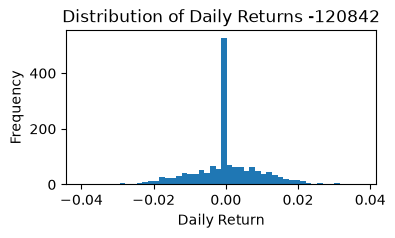

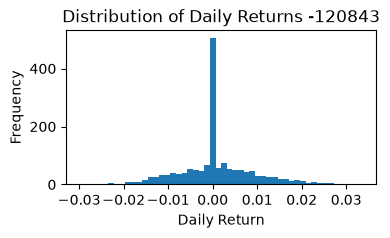

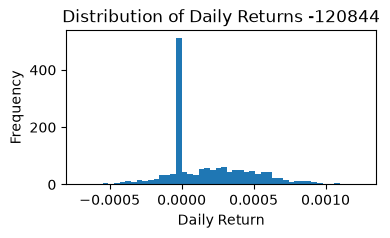

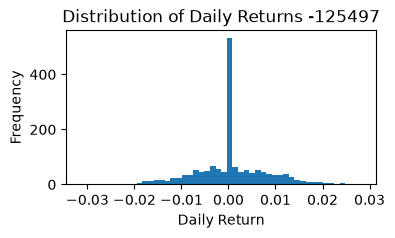

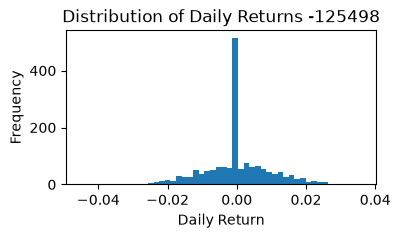

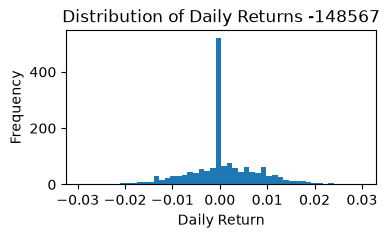

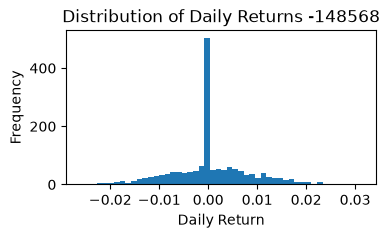

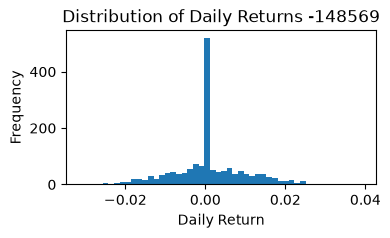

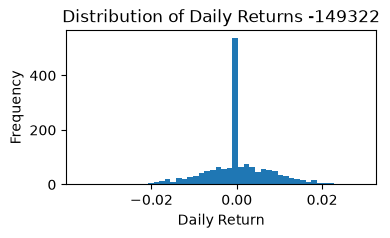

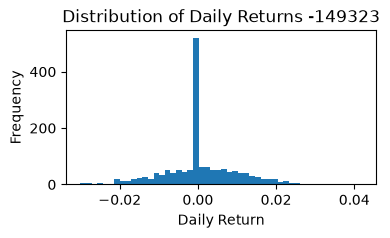

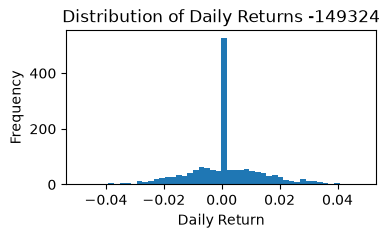

In [198]:
for scheme in nav_df["amfi_code"].unique():
    scheme_df=nav_df[nav_df["amfi_code"]==scheme]

    plt.figure(figsize=(4,2))
    plt.hist(scheme_df["daily_return"].dropna(), bins=50)
    plt.title(f"Distribution of Daily Returns -{scheme}")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.show()

In [199]:
nav_df.head()

,date,amfi_code,nav,daily_return
0,2022-01-03,100016,520.4608,NaN
1,2022-01-04,100016,515.0971,-0.010306
2,2022-01-05,100016,521.7239,0.012865
3,2022-01-06,100016,515.7880,-0.011377
4,2022-01-07,100016,515.1639,-0.001210


In [200]:
print("Minimum Return :", nav_df["daily_return"].min())
print("Maximum Return :", nav_df["daily_return"].max())
print("Missing Values :", nav_df["daily_return"].isnull().sum())

Minimum Return : -0.058102013949189124
Maximum Return : 0.06471309359097144
Missing Values : 40


In [201]:
nav_df.to_csv("returns_computed.csv",index=False)

## Task 2: CAGR Analysis

Calculate the Compound Annual Growth Rate (CAGR) for 1-year, 3-year, and 5-year periods for all 40 mutual funds and generate a comparative report.

In [202]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [203]:
cagr_report = []

for scheme, scheme_df in nav_df.groupby("amfi_code"):

    scheme_df = scheme_df.sort_values("date").copy()

    latest_date = scheme_df["date"].max()
    latest_nav = scheme_df.iloc[-1]["nav"]

    cagr_values = {}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        temp = scheme_df[scheme_df["date"] >= start_date]

        if len(temp) > 0:

            start_nav = temp.iloc[0]["nav"]

            cagr_values[f"CAGR_{years}Y"] = calculate_cagr(
                start_nav,
                latest_nav,
                years
            )

        else:

            cagr_values[f"CAGR_{years}Y"] = np.nan

    cagr_report.append({
        "amfi_code": scheme,
        **cagr_values
    })

In [204]:
cagr_report_df = pd.DataFrame(cagr_report)

cagr_report_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [205]:
cagr_report_df.to_csv("cagr_report.csv", index=False)

## Task 3: Sharpe Ratio

Calculate the Sharpe Ratio for each mutual fund using a risk-free rate of 6.5% and rank all funds based on their risk-adjusted returns.

In [206]:
rf = 0.065
daily_rf = rf / 252

In [207]:
sharpe_data = []

for scheme in nav_df["amfi_code"].unique():

    scheme_df = nav_df[nav_df["amfi_code"] == scheme]

    returns = scheme_df["daily_return"].dropna()

    mean_return = returns.mean()

    std_return = returns.std()

    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_data.append({
        "amfi_code": scheme,
        "Sharpe Ratio": sharpe
    })

In [208]:
sharpe_df = pd.DataFrame(sharpe_data)

sharpe_df.head()

,amfi_code,Sharpe Ratio
0,100016,-0.321019
1,100025,-1.039941
2,100033,0.808268
3,101206,0.717409
4,101207,0.052618


In [209]:
sharpe_df["Rank"] = sharpe_df["Sharpe Ratio"].rank(
    ascending=False,
    method="dense"
)

In [210]:
sharpe_df = sharpe_df.sort_values("Rank")

sharpe_df

,amfi_code,Sharpe Ratio,Rank
34,148567,1.068224,1.0
30,120843,0.965561,2.0
36,148569,0.919047,3.0
25,120505,0.883256,4.0
19,119551,0.860977,5.0
38,149323,0.832885,6.0
2,100033,0.808268,7.0
9,118632,0.758851,8.0
16,119094,0.730547,9.0
3,101206,0.717409,10.0


In [211]:
sharpe_df.to_csv("sharpe_values.csv", index=False)

## Task 4: Sortino Ratio

Calculate the Sortino Ratio for all funds by considering only downside volatility and compare their downside risk-adjusted performance.

In [212]:
daily_rf

0.00025793650793650796

In [213]:
sortino_data = []

for scheme, scheme_df in nav_df.groupby("amfi_code"):

    returns = scheme_df["daily_return"].dropna()

    downside_returns = returns[returns < 0]

    mean_return = returns.mean()

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_data.append({
        "amfi_code": scheme,
        "Sortino Ratio": sortino
    })

In [214]:
sortino_df = pd.DataFrame(sortino_data)

In [215]:
sortino_df["Rank"] = sortino_df["Sortino Ratio"].rank(
    ascending=False,
    method="dense"
)

In [216]:
sortino_df = sortino_df.sort_values("Rank")

sortino_df

,amfi_code,Sortino Ratio,Rank
34,148567,1.490739,1.0
30,120843,1.479503,2.0
36,148569,1.352815,3.0
19,119551,1.291483,4.0
25,120505,1.285843,5.0
38,149323,1.167793,6.0
2,100033,1.144216,7.0
9,118632,1.098880,8.0
21,119598,1.067256,9.0
24,120504,1.063964,10.0


In [217]:
sortino_df.to_csv("sortino_values.csv", index=False)

## Task 5: Alpha & Beta

Estimate Alpha and Beta for each mutual fund using Ordinary Least Squares (OLS) regression against the NIFTY100 benchmark. Alpha is annualized by multiplying the regression intercept by 252.

In [218]:
benchmark_df = pd.read_csv(r"D:\Bluestock\Project\Data\Raw\10_benchmark_indices.csv")

benchmark_df = benchmark_df[benchmark_df["index_name"] == "NIFTY100"]

benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df.sort_values("date")

In [219]:
benchmark_df["benchmark_return"] = benchmark_df["close_value"].pct_change()

In [220]:
alpha_beta = []

for scheme, scheme_df in nav_df.groupby("amfi_code"):

    fund = scheme_df[["date", "daily_return"]]

    merged = pd.merge(
        fund,
        benchmark_df[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha_beta.append({
        "amfi_code": scheme,
        "Alpha": intercept * 252,
        "Beta": slope
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.to_csv("alpha_beta.csv", index=False)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


## Task 6: Maximum Drawdown

Compute the running maximum NAV, calculate the drawdown series, identify the Maximum Drawdown for each fund, and determine the worst drawdown date.

In [221]:
max_dd = []

for scheme, scheme_df in nav_df.groupby("amfi_code"):

    scheme_df = scheme_df.sort_values("date").copy()

    scheme_df["running_max"] = scheme_df["nav"].cummax()

    scheme_df["drawdown"] = (
        scheme_df["nav"] / scheme_df["running_max"]
    ) - 1

    max_drawdown = scheme_df["drawdown"].min()

    worst_date = scheme_df.loc[
        scheme_df["drawdown"].idxmin(),
        "date"
    ]

    max_dd.append({
        "amfi_code": scheme,
        "Maximum Drawdown": max_drawdown,
        "Worst Drawdown Date": worst_date
    })

max_drawdown_df = pd.DataFrame(max_dd)

max_drawdown_df.to_csv("max_drawdown.csv", index=False)

max_drawdown_df.head()

,amfi_code,Maximum Drawdown,Worst Drawdown Date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


## Task 7: Fund Scorecard

Create a composite score for each mutual fund using weighted rankings of 3-Year CAGR, Sharpe Ratio, Alpha, Expense Ratio, and Maximum Drawdown to identify the best-performing funds.

In [222]:
scorecard = cagr_report_df.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    max_drawdown_df[["amfi_code", "Maximum Drawdown"]],
    on="amfi_code"
)

In [223]:
master_df = pd.read_csv(r"D:\Bluestock\Project\Data\Raw\01_fund_master.csv")

scorecard = scorecard.merge(
    master_df[["amfi_code", "expense_ratio_pct","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [224]:
scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,scheme_name
0,100016,-0.022243,0.012926,0.023168,-0.321019,0.037476,-0.247344,1.55,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.037050,0.039164,0.039127,-1.039941,0.042818,-0.043083,0.56,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.532324,0.324425,0.260741,0.808268,0.271954,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.479241,0.289677,0.204427,0.717409,0.213998,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.239860,-0.041524,0.069533,0.052618,0.108971,-0.354469,1.53,ABSL Small Cap Fund - Regular - Growth


In [225]:
scorecard["Return Rank"] = scorecard["CAGR_3Y"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [226]:
scorecard.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,scheme_name,Return Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank
0,100016,-0.022243,0.012926,0.023168,-0.321019,0.037476,-0.247344,1.55,HDFC Top 100 Fund - Regular Plan - Growth,35.0,34.0,39.0,32.0,34.0
1,100025,0.037050,0.039164,0.039127,-1.039941,0.042818,-0.043083,0.56,HDFC Short Term Debt Fund - Regular - Growth,34.0,37.0,38.0,2.0,4.0
2,100033,0.532324,0.324425,0.260741,0.808268,0.271954,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.0,7.0,6.0,17.0,20.0
3,101206,0.479241,0.289677,0.204427,0.717409,0.213998,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth,9.0,10.0,12.0,36.5,9.0
4,101207,-0.239860,-0.041524,0.069533,0.052618,0.108971,-0.354469,1.53,ABSL Small Cap Fund - Regular - Growth,39.0,27.0,27.0,28.5,38.0


In [227]:
n = len(scorecard)

scorecard["Return Score"] = n - scorecard["Return Rank"] + 1
scorecard["Sharpe Score"] = n - scorecard["Sharpe Rank"] + 1
scorecard["Alpha Score"] = n - scorecard["Alpha Rank"] + 1
scorecard["Expense Score"] = n - scorecard["Expense Rank"] + 1
scorecard["Drawdown Score"] = n - scorecard["Drawdown Rank"] + 1

In [228]:
scorecard["Composite Score"] = (
      0.30 * scorecard["Return Score"]
    + 0.25 * scorecard["Sharpe Score"]
    + 0.20 * scorecard["Alpha Score"]
    + 0.15 * scorecard["Expense Score"]
    + 0.10 * scorecard["Drawdown Score"]
)

In [229]:
scorecard["Fund Score"] = (
    (scorecard["Composite Score"] - scorecard["Composite Score"].min())
    /
    (scorecard["Composite Score"].max() - scorecard["Composite Score"].min())
) * 100

In [230]:
scorecard = scorecard.sort_values("Fund Score", ascending=False)

scorecard["Overall Rank"] = range(1, len(scorecard) + 1)

In [231]:
scorecard.to_csv("fund_scorecard.csv", index=False)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe Ratio,Alpha,Maximum Drawdown,expense_ratio_pct,scheme_name,Return Rank,...,Expense Rank,Drawdown Rank,Return Score,Sharpe Score,Alpha Score,Expense Score,Drawdown Score,Composite Score,Fund Score,Overall Rank
34,148567,0.203607,0.340009,0.267993,1.068224,0.269838,-0.112657,1.46,Mirae Asset Large Cap Fund - Regular - Growth,2.0,...,23.0,8.0,39.0,40.0,34.0,18.0,33.0,34.500,100.000000,1
25,120505,0.296047,0.317775,0.283768,0.883256,0.292636,-0.181885,1.36,ICICI Pru Midcap Fund - Regular - Growth,5.0,...,15.0,25.0,36.0,37.0,38.0,26.0,16.0,33.150,95.263158,2
30,120843,0.266571,0.295828,0.267425,0.965561,0.273305,-0.129740,1.45,Kotak Flexicap Fund - Regular - Growth,7.0,...,22.0,13.0,34.0,39.0,36.0,19.0,28.0,32.800,94.035088,3
2,100033,0.532324,0.324425,0.260741,0.808268,0.271954,-0.162172,1.38,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,4.0,...,17.0,20.0,37.0,34.0,35.0,24.0,21.0,32.300,92.280702,4
24,120504,0.130643,0.324874,0.202340,0.714682,0.211948,-0.125883,0.80,ICICI Pru Bluechip Fund - Direct - Growth,3.0,...,12.0,12.0,38.0,30.0,28.0,29.0,29.0,31.750,90.350877,5
16,119094,0.222611,0.351118,0.244453,0.730547,0.260767,-0.209609,1.38,Axis Midcap Fund - Regular - Growth,1.0,...,17.0,28.0,40.0,32.0,32.0,24.0,13.0,31.300,88.771930,6
19,119551,0.604373,0.304565,0.223849,0.860977,0.232010,-0.150124,1.54,SBI Bluechip Fund - Regular Plan - Growth,6.0,...,30.5,17.0,35.0,36.0,31.0,10.5,24.0,29.675,83.070175,7
36,148569,0.397518,0.291789,0.276299,0.919047,0.282704,-0.163967,1.60,Mirae Asset Tax Saver Fund - Regular - Growth,8.0,...,36.5,21.0,33.0,38.0,37.0,4.5,20.0,29.475,82.368421,8
21,119598,0.827761,0.266699,0.280332,0.711690,0.303370,-0.287060,1.43,SBI Small Cap Fund - Regular Plan - Growth,12.0,...,21.0,36.0,29.0,28.0,40.0,20.0,5.0,27.200,74.385965,9
3,101206,0.479241,0.289677,0.204427,0.717409,0.213998,-0.112916,1.60,ABSL Frontline Equity Fund - Regular - Growth,9.0,...,36.5,9.0,32.0,31.0,29.0,4.5,32.0,27.025,73.771930,10


## Task 8: Benchmark Comparison & Tracking Error

Compare the performance of the top five mutual funds with the NIFTY50 and NIFTY100 benchmarks over the last three years. Compute Tracking Error to measure how closely each fund follows the benchmark.

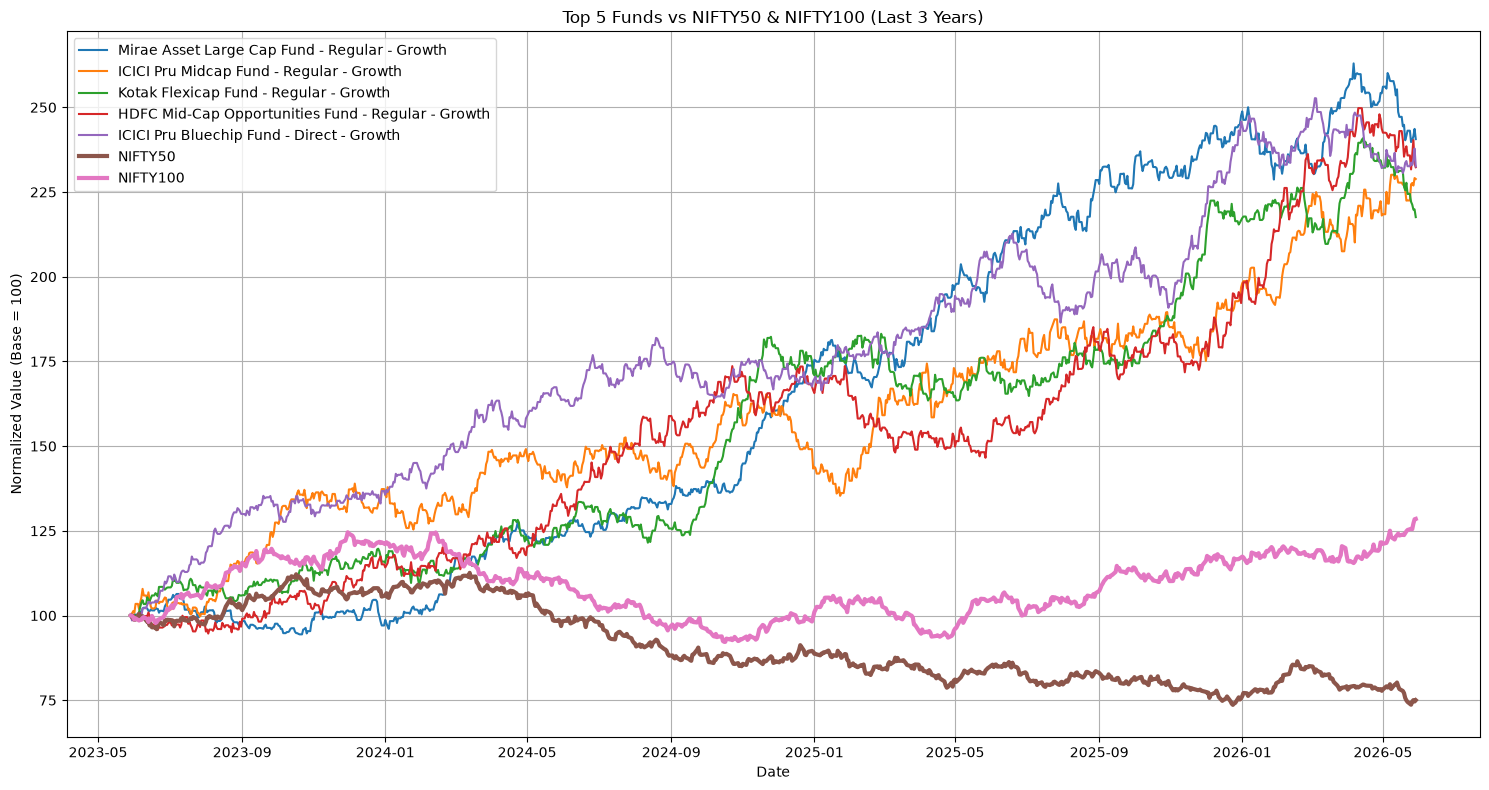

,amfi_code,scheme_name,Tracking Error
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.187867
1,120505,ICICI Pru Midcap Fund - Regular - Growth,0.232515
2,120843,Kotak Flexicap Fund - Regular - Growth,0.206410
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.224838
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.187312


In [232]:
top5 = scorecard.head(5)["amfi_code"].tolist()

benchmark_all = pd.read_csv(r"D:\Bluestock\Project\Data\Raw\10_benchmark_indices.csv")

benchmark_all["date"] = pd.to_datetime(benchmark_all["date"])

nifty50 = benchmark_all[benchmark_all["index_name"] == "NIFTY50"].copy()
nifty100 = benchmark_all[benchmark_all["index_name"] == "NIFTY100"].copy()

nifty50 = nifty50.sort_values("date")
nifty100 = nifty100.sort_values("date")

end_date = nav_df["date"].max()
start_date = end_date - pd.DateOffset(years=3)

plt.figure(figsize=(15,8))

tracking_error = []

for fund in top5:

    fund_df = nav_df[
        (nav_df["amfi_code"] == fund) &
        (nav_df["date"] >= start_date)
    ].copy()

    fund_df = fund_df.sort_values("date")

    fund_df["Normalized"] = (
        fund_df["nav"] / fund_df["nav"].iloc[0]
    ) * 100

    scheme_name = scorecard.loc[
        scorecard["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    plt.plot(
        fund_df["date"],
        fund_df["Normalized"],
        label=scheme_name
    )

    merged = pd.merge(
        fund_df[["date", "daily_return"]],
        benchmark_df[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    te = (
        (merged["daily_return"] -
         merged["benchmark_return"]).std()
    ) * np.sqrt(252)

    tracking_error.append({
        "amfi_code": fund,
        "scheme_name": scheme_name,
        "Tracking Error": te
    })

nifty50_plot = nifty50[nifty50["date"] >= start_date].copy()

nifty50_plot["Normalized"] = (
    nifty50_plot["close_value"] /
    nifty50_plot["close_value"].iloc[0]
) * 100

plt.plot(
    nifty50_plot["date"],
    nifty50_plot["Normalized"],
    linewidth=3,
    label="NIFTY50"
)

nifty100_plot = nifty100[nifty100["date"] >= start_date].copy()

nifty100_plot["Normalized"] = (
    nifty100_plot["close_value"] /
    nifty100_plot["close_value"].iloc[0]
) * 100

plt.plot(
    nifty100_plot["date"],
    nifty100_plot["Normalized"],
    linewidth=3,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("benchmark_chart.png")

plt.show()

tracking_error_df = pd.DataFrame(tracking_error)

tracking_error_df.to_csv("tracking_error.csv", index=False)

tracking_error_df